In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import copy
import math
x_train=np.array([1.0,3.0])
y_train=np.array([300.0,500.0])
# def price_predict(x,w,b):
#     m=x.shape[0]
#     f_wb=np.zeros(m)
#     price=0
#     for i in range(m):
#         f_wb[i]=w*(x[i])+b
#         price+=f_wb[i]
#         result=price
#     return result

#成本函数，用于表达价格预测的准确性，越小越准确
def cost_function(x,y,w,b):
    m=x.shape[0]
    cost=0
    cost_total=0
    for i in range(m):
        cost=(w*(x[i])+b-y[i])**2
        cost_total+=cost
        result=(1/(2*m))*cost_total
    return result

#获取计算机在不断学习之中更新的参数值 w=w-alpha*(dJ(w,b)/dw) 
def Partial_j(x,y,w,b):
    m=x.shape[0]
    j_wb_w1=0
    j_wb_b1=0
    for i in range(m):
        f_wb=w*x[i]+b
        j_wb_w_i=(f_wb-y[i])*x[i]
        j_wb_b_i=(f_wb-y[i])
        j_wb_w1+=j_wb_w_i
        j_wb_b1+=j_wb_b_i
    j_wb_b=j_wb_b1/m
    j_wb_w=j_wb_w1/m
    return j_wb_w,j_wb_b

def Gradient(x,y,w,b):
    new_w=w-Partial_j(x,y,w,b)[0]
    new_b=b-Partial_j(x,y,w,b)[1]
    return new_w,new_b
new_w=Gradient(x_train,y_train,200,100)[0]
new_b=Gradient(x_train,y_train,200,100)[1]

#批量化梯度下降
#变量信息：x,y 传入的w和b 学习指数 循环次数 函数1 2 
def gradient_descent(x,y,w_in,b_in,alpha,num_iters,cost_function,Partial_j):
    w=copy.deepcopy(w_in)     #深度复制，创建一个值相同但是相互独立的变量
    j_history=[]
    p_history=[]              #用于存储梯度下降的时候的变量值
    w=w_in
    b=b_in                    #定义并传入值
    for i in range(num_iters):
        dj_dw=Partial_j(x,y,w,b)[0]
        dj_db=Partial_j(x,y,w,b)[1]
        w=w-alpha*dj_dw
        b=b-alpha*dj_db
        if i<100000:
           j_history.append(cost_function(x,y,w,b))
           p_history.append([w,b])
        if i%math.ceil(num_iters/10)==0:
            print(f"迭代次数:{i:4}:价格为{j_history[-1]:0.2e}",f"dj_dw:{dj_dw:0.3e},dj_db:{dj_db:0.3e}",f"w:{w:0.3e},b:{b:0.3e}")
            #打印出循环次数、当下变量函数值，当下偏导数值，当下值减去alpha偏导得出来的值
    return w,b,j_history,p_history     #返回迭代了之后的参数值

#开始设置梯度下降函数迭代的参数
w_init=0
b_init=0        #初始化两个参数，用与梯度下降函数从零开始调用，迭代循环
num_iters=10000       #！！！可随时调参
alpha=1.0e-2
w_train,b_train,j_list,p_tuple=gradient_descent(x_train,y_train,w_init,b_init,alpha,num_iters,cost_function,Partial_j)
print(f"(w,b)经过梯度下降循环迭代得到值为：({w_train:8.4f},{b_train:8.4f})")









迭代次数:   0:价格为7.56e+04 dj_dw:-9.000e+02,dj_db:-4.000e+02 w:9.000e+00,b:4.000e+00
迭代次数:1000:价格为5.92e+01 dj_dw:1.727e+00,dj_db:-4.170e+00 w:1.101e+02,b:1.757e+02
迭代次数:2000:价格为1.91e+00 dj_dw:3.102e-01,dj_db:-7.488e-01 w:1.018e+02,b:1.956e+02
迭代次数:3000:价格为6.15e-02 dj_dw:5.570e-02,dj_db:-1.345e-01 w:1.003e+02,b:1.992e+02
迭代次数:4000:价格为1.98e-03 dj_dw:1.000e-02,dj_db:-2.415e-02 w:1.001e+02,b:1.999e+02
迭代次数:5000:价格为6.40e-05 dj_dw:1.796e-03,dj_db:-4.336e-03 w:1.000e+02,b:2.000e+02
迭代次数:6000:价格为2.06e-06 dj_dw:3.225e-04,dj_db:-7.786e-04 w:1.000e+02,b:2.000e+02
迭代次数:7000:价格为6.65e-08 dj_dw:5.791e-05,dj_db:-1.398e-04 w:1.000e+02,b:2.000e+02
迭代次数:8000:价格为2.14e-09 dj_dw:1.040e-05,dj_db:-2.510e-05 w:1.000e+02,b:2.000e+02
迭代次数:9000:价格为6.91e-11 dj_dw:1.867e-06,dj_db:-4.508e-06 w:1.000e+02,b:2.000e+02
(w,b)经过梯度下降循环迭代得到值为：(100.0000,200.0000)


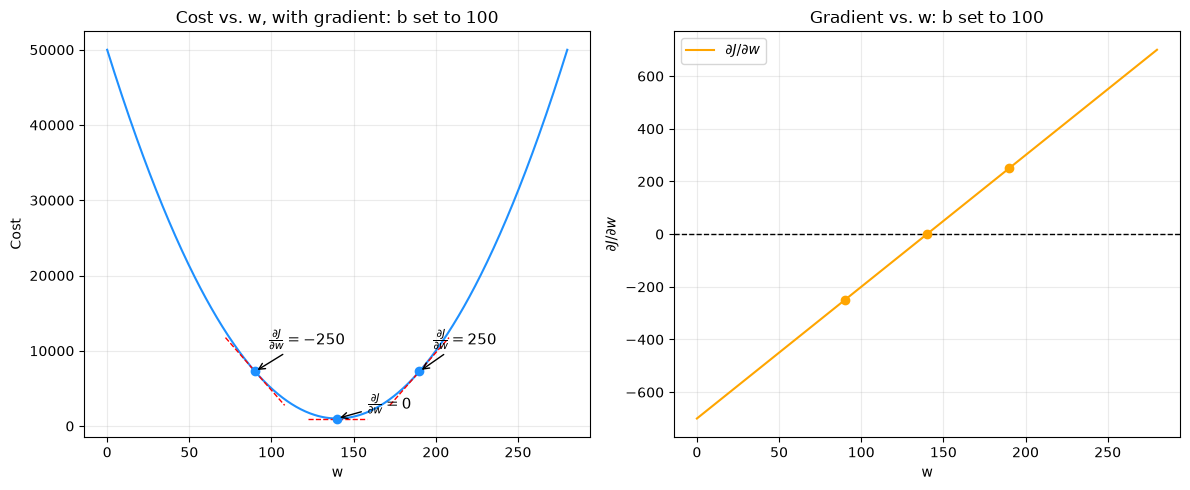

In [13]:
# 固定 b=100，准备 Cost 和偏导数数据
b_fixed = 100
w_values = np.linspace(0, 280, 500)
cost_values = np.array([cost_function(x_train, y_train, w, b_fixed) for w in w_values])
gradient_values = np.array([Partial_j(x_train, y_train, w, b_fixed)[0] for w in w_values])

# 选取梯度为 -250、0、250 的三个位置
w_min = np.sum(x_train * (y_train - b_fixed)) / np.sum(x_train ** 2)
point_w = np.array([w_min - 50, w_min, w_min + 50])
point_cost = np.array([cost_function(x_train, y_train, w, b_fixed) for w in point_w])
point_grad = np.array([Partial_j(x_train, y_train, w, b_fixed)[0] for w in point_w])

plt.figure(figsize=(12, 5))

# 左图：Cost 曲线和各点处的切线
plt.subplot(1, 2, 1)
plt.plot(w_values, cost_values, color='dodgerblue')
plt.scatter(point_w, point_cost, color='dodgerblue', zorder=3)
for w0, cost0, grad0 in zip(point_w, point_cost, point_grad):
    tangent_w = np.array([w0 - 18, w0 + 18])
    tangent_cost = cost0 + grad0 * (tangent_w - w0)
    plt.plot(tangent_w, tangent_cost, 'r--', linewidth=1)

text_offsets = [(8, 3500), (18, 1200), (8, 3500)]
for w0, cost0, grad0, (dx, dy) in zip(point_w, point_cost, point_grad, text_offsets):
    plt.annotate(rf'$\frac{{\partial J}}{{\partial w}}={grad0:.0f}$',
                 xy=(w0, cost0), xytext=(w0 + dx, cost0 + dy),
                 arrowprops=dict(arrowstyle='->', color='black'), fontsize=11)
plt.xlabel('w')
plt.ylabel('Cost')
plt.title('Cost vs. w, with gradient: b set to 100')
plt.grid(alpha=0.25)

# 右图：Cost 关于 w 的偏导数
plt.subplot(1, 2, 2)
plt.plot(w_values, gradient_values, color='orange', label=r'$\partial J/\partial w$')
plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.scatter(point_w, point_grad, color='orange', zorder=3)
plt.xlabel('w')
plt.ylabel(r'$\partial J/\partial w$')
plt.title('Gradient vs. w: b set to 100')
plt.grid(alpha=0.25)
plt.legend()

plt.tight_layout()
plt.show()
